Assumptions
- all questions have a refusal answer at the very end
- none of the questions have partial options, i.e., no 1.5

In [1]:
import pandas as pd
import numpy as np
import os
import swifter
from scipy.stats import wasserstein_distance
import ast
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', None)

C:\Users\isen1\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#### Before: Wasserstein distance between distributions
#### Now: Majority answer match

1. get the human distributions: split it into refusal and non-refusal (D_H)
2. from D_H, get the most popular answer, H_M i.e, option with highest probability
3. get the LLM logprobs
4. convert LLM logprobs to distributions: split it into refusal and non-refusal (D_M)
5. from D_M, get the most popular answer A_M, i.e, option with highest probability
6. count for how many out of 100, do A_M and H_M match

In [2]:
versions = True

In [4]:
import opinionqa_helpers as ph
from opinionqa_helpers_custom import compute_match, get_probs

In [5]:
LLMs = ["merged_results_user_OLMo-2-0325-32B-Instruct",
        "merged_results_user_OLMo-2-1124-7B-Instruct",
        "merged_results_user_Llama-3.1-8B-Instruct",
        "merged_results_user_Llama-3.3-70B-Instruct",
        "merged_results_user_gemma-3-27b-it"
       ]

In [5]:
opinionqa_human_response_path = "../../opinions_qa/data/human_resp/"
llm_result_path = "../../data/results/Q&A/"

ATP = "American_Trends_Panel_"
genders = ['Male', 'Female']
races = ['White', 'Asian', 'Hispanic', 'Black'] 

RESULT_DIR = '../../opinions_qa/data/runs'

#### read the LLM output to get all survey wave IDs and question IDs

In [6]:
data = {}

for llm in LLMs:
    data[llm] = pd.read_csv(llm_result_path+llm+'.csv')

data[llm]['qa_key'][:5]

0    INEQ8_g_W54
1    INEQ8_h_W54
2    INEQ8_i_W54
3    INEQ8_j_W54
4     INEQ11_W54
Name: qa_key, dtype: object

In [7]:
question_IDs = {}
for qa_key in data[llm].qa_key:
    wave_id = qa_key.split('_')[-1]
    if wave_id in question_IDs:
        if qa_key not in question_IDs[wave_id]:
            question_IDs[wave_id].append(qa_key)
    else:
        question_IDs[wave_id] = [qa_key]

In [8]:
for question_id in question_IDs:
    print(question_id, len(question_IDs[question_id]), question_IDs[question_id][:5])

W54 21 ['INEQ8_g_W54', 'INEQ8_h_W54', 'INEQ8_i_W54', 'INEQ8_j_W54', 'INEQ11_W54']
W82 56 ['GAP21Q4_a_W82', 'GAP21Q4_b_W82', 'GAP21Q4_c_W82', 'GAP21Q4_d_W82', 'GAP21Q4_e_W82']
W92 23 ['USEXCEPT_W92', 'WHADVANT_W92', 'BILLION_W92', 'FREECOLL_W92', 'USMILSIZ_W92']


#### get the human responses for these questions

This should be a dataframe with the following columns:
- wave_id
- race
- gender
- human answer distribution: a dictionary with the different options and their support

In [9]:
data[llm].columns

Index(['Unnamed: 0', 'prompt_id', 'answer_dist', 'conf_out_dist', 'seed',
       'prompt', 'template', 'race', 'gender', 'qa_key', 'qa_options', 'task',
       'persona_string', 'persona_type', 'prompt_version', 'prompt_perplexity',
       'prompt_entropy', 'answer_dist_clean', 'confidence_dist'],
      dtype='object')

### for now reuse the OpinionQA code, but might be nice to reimplement this without having to rely on the LLM models they used

#### get human response distributions

To get the human distributions using the code from the OpinionQA paper, we have to download at least one run from https://worksheets.codalab.org/bundles/0xd70e124707194a77b73e5d20ae074ee9 

In [10]:
human_dfs = []
PEW_SURVEY_LIST = ph.PEW_SURVEY_LIST
SURVEY_LIST = [f'American_Trends_Panel_{SURVEY_WAVE}' for SURVEY_WAVE in question_IDs]

for SURVEY_NAME in SURVEY_LIST:
    RESULT_FILES = [f for f in os.listdir(RESULT_DIR) if SURVEY_NAME in f]
    ## I.S: extra step to restrict models
    RESULT_FILES_ = []
    for mname in ph.MODEL_NAMES:
        for rf in RESULT_FILES:
            if mname in rf:
                RESULT_FILES_.append(rf)
                
    RESULT_FILES = RESULT_FILES_
    human_answers = pd.read_csv(opinionqa_human_response_path+SURVEY_NAME\
                                +'/responses.csv')
    info_df = pd.read_csv(opinionqa_human_response_path+SURVEY_NAME\
                                +'/info.csv')
    info_df['option_ordinal'] = info_df.apply(lambda x: eval(x['option_ordinal']), axis=1)
    info_df['references'] = info_df.apply(lambda x: eval(x['references']), axis=1)
    # print(RESULT_FILES)
    model_df = ph.get_model_opinions(RESULT_DIR, RESULT_FILES, info_df)
    
    md_df = pd.read_csv(opinionqa_human_response_path+ATP+wave_id\
                                +'/metadata.csv')
    md_df['options'] = md_df.apply(lambda x: eval(x['options']), axis=1)
    md_order = {'Overall': {'Overall': 0}}
    md_order.update({k: {o: oi for oi, o in enumerate(opts)} for k, opts in zip(md_df['key'],
                                                                                md_df['options'])})

    for race in races:
        human_answer_subset = human_answers[human_answers['RACE'] == race]
        subset_df = pd.concat([ph.extract_human_opinions(human_answer_subset, 
                                                        model_df, 
                                                        md_df, 
                                                        demographic='SEX', 
                                                        wave=int(SURVEY_NAME.split('_W')[1]))])
        subset_df['RACE'] = [race] * len(subset_df)
        human_dfs.append(subset_df)
    
human_df = pd.concat(human_dfs, ignore_index = True)

opinions_qa_survey=Pew_American_Trends_Panel_W54,num_logprobs=10,context=default,num_train_trials=1,model=ai21_j1-jumbo,num_train_trials=1
ai21_j1-jumbo default
----------------------------------------------------------------------------------------------------
opinions_qa_survey=Pew_American_Trends_Panel_W82,num_logprobs=10,context=default,num_train_trials=1,model=ai21_j1-jumbo,num_train_trials=1
ai21_j1-jumbo default
----------------------------------------------------------------------------------------------------


C:\Users\isen1\AppData\Local\Temp\ipykernel_24568\349827834.py:15: DtypeWarning: Columns (42,44) have mixed types. Specify dtype option on import or set low_memory=False.
  human_answers = pd.read_csv(opinionqa_human_response_path+SURVEY_NAME\


opinions_qa_survey=Pew_American_Trends_Panel_W92,num_logprobs=10,context=default,num_train_trials=1,model=ai21_j1-jumbo,num_train_trials=1
ai21_j1-jumbo default
----------------------------------------------------------------------------------------------------


In [11]:
human_df.head()

,qkey,attribute,group,D_H,R_H,RACE
0,ECIMPg_W54,SEX,Female,"[0.8400803023779018, 0.02512591991547269, 0.1347937777066256]",0.005721,White
1,ECIMPg_W54,SEX,Male,"[0.7795297645436706, 0.017091113786873356, 0.20337912166945615]",0.003558,White
2,GOVRESP_a_W54,SEX,Female,"[0.5682648634054637, 0.4317351365945363]",0.008805,White
3,GOVRESP_a_W54,SEX,Male,"[0.4310631087102742, 0.5689368912897258]",0.002675,White
4,ECON3_d_W54,SEX,Female,"[0.4475474011493372, 0.30744208721277066, 0.17449972309810882, 0.07051078853978335]",0.013140,White


### get model distributions

In [12]:
get_probs(ast.literal_eval(data[llm]['answer_dist_clean'][0]), separate_refusal=True)

(array([9.94779870e-01, 5.22012561e-03, 4.34068436e-09, 3.08264287e-12]),
 6.7432542193296695e-15)

In [13]:
for llm in LLMs:
    data[llm]['D_M'] = [get_probs(ast.literal_eval(i), separate_refusal = True
                       )[0] for i in data[llm]['answer_dist_clean']]
    data[llm]['D_R'] = [get_probs(ast.literal_eval(i), separate_refusal = True
                       )[1] for i in data[llm]['answer_dist_clean']]
    data[llm]['A_M'] = [np.argmax(i) for i in data[llm]['D_M']]

### get the option with the highest probability

In [14]:
human_df['A_H'] = [np.argmax(i) for i in human_df['D_H']]

In [15]:
data[llm][['A_M', 'D_M']].head()

,A_M,D_M
0,0,"[0.9947798700433848, 0.005220125612848477, 4.340684364411622e-09, 3.0826428656544318e-12]"
1,2,"[2.2897348107192762e-11, 5.384940135615306e-13, 0.9999999847465846, 1.522997951240342e-08]"
2,0,"[0.9933071471513152, 0.006692851254144532, 1.594483821388228e-09, 5.637696307069923e-14]"
3,1,"[0.0019267342249631426, 0.9980728737318922, 3.9202928333606423e-07, 1.3861188937994088e-11]"
4,0,"[0.9999999317439628, 6.825603724121505e-08]"


In [16]:
human_df[['D_H', 'A_H']].head()

,D_H,A_H
0,"[0.8400803023779018, 0.02512591991547269, 0.1347937777066256]",0
1,"[0.7795297645436706, 0.017091113786873356, 0.20337912166945615]",0
2,"[0.5682648634054637, 0.4317351365945363]",0
3,"[0.4310631087102742, 0.5689368912897258]",1
4,"[0.4475474011493372, 0.30744208721277066, 0.17449972309810882, 0.07051078853978335]",0


### match based on demographic groups and prompt types

In [17]:
qa_demo_map = {'F': 'Female',
               'M' : 'Male'}

genders = ['F', 'M']
persona_types = data[llm]['persona_type'].unique()
persona_strings = data[llm]['persona_string'].unique()
prompt_versions = data[llm]['prompt_version'].unique()

baseline_df_rows = [] 

In [18]:
### get random baseline
for gender in genders:
    human_df_subset = human_df[human_df['group'] == qa_demo_map[gender]]
    
    for race in races:
        human_df_subset_r = human_df_subset[human_df_subset['RACE'] == race]
        
        ## get random bound
        
        for i in range(100):
            alignment = compute_match(human_df_subset_r, baseline = True)
            baseline_df_row = [gender, race, 'random',
                                        alignment]
            baseline_df_rows.append(baseline_df_row)

baseline_df = pd.DataFrame(baseline_df_rows)
baseline_df.columns = ['gender', 'race', 'persona_type','alignment']
means = baseline_df.groupby(['gender', 'race', 'persona_type'])['alignment'].mean().unstack()
stds = baseline_df.groupby(['gender', 'race', 'persona_type'])['alignment'].std().unstack()
bl_df = pd.concat([means.T, stds.T]).T
bl_df.columns = ['mean', 'std']
bl_df

mean       std
gender race                        
F      Asian     0.241077  0.023630
       Black     0.241886  0.025372
       Hispanic  0.240505  0.029964
       White     0.239125  0.026338
M      Asian     0.237778  0.025376
       Black     0.242660  0.025545
       Hispanic  0.244983  0.027567
       White     0.241582  0.023033

In [19]:
bl_df.mean()

mean    0.241199
std     0.025853
dtype: float64

In [20]:
### get models' results

alignment_df = {}

for llm in LLMs:
    alignment_df_rows = []
    for gender in genders:
        df = data[llm]
        model_df_subset = df[df['gender'] == gender]
        human_df_subset = human_df[human_df['group'] == qa_demo_map[gender]]
    
        for race in races:
            model_df_subset_race = model_df_subset[model_df_subset['race'] == race]
            human_df_subset_r = human_df_subset[human_df_subset['RACE'] == race]
        
            for persona_type in ['dem_cat+descr', 'dem_descr', 'name']:
                model_df_subset_pt = model_df_subset_race[model_df_subset_race['persona_type']\
                                                   == persona_type]
            
                
            
                for persona_string in persona_strings:
                    model_df_subset_ps = model_df_subset_pt[model_df_subset_pt['persona_string']\
                                                        == persona_string]
                    if versions:
                        for prompt_version in prompt_versions:
                            model_df_subset_pv = model_df_subset_ps[model_df_subset_ps['prompt_version'] == \
                                                      prompt_version]
                            # print(len(model_df_subset_pv))
                            alignment = compute_match(human_df_subset_r, model_df_subset_pv)
                            alignment_df_row = [gender, race, persona_type,
                                        persona_string, prompt_version,
                                        alignment]
                            alignment_df_rows.append(alignment_df_row)
                    else:
                        alignment = compute_match(human_df_subset_r, model_df_subset_ps)
                        alignment_df_row = [gender, race, persona_type,
                                        persona_string, # prompt_version,
                                        alignment]
                        alignment_df_rows.append(alignment_df_row)
                        '''
                        # disaggregating names
                        if persona_type != 'name':
                            alignment = compute_match(human_df_subset_r, model_df_subset_ps)
                            alignment_df_row = [gender, race, persona_type,
                                        persona_string, prompt_version,
                                        alignment]
                            alignment_df_rows.append(alignment_df_row)
                        else:
                            for i in range(10):
                                alignment = compute_match(human_df_subset_r,
                                                          model_df_subset_ps.iloc[i*100:(i+1)*100])
                                alignment_df_row = [gender, race, persona_type,
                                        persona_string, prompt_version,
                                        alignment]
                                alignment_df_rows.append(alignment_df_row)
                        '''
                        


    alignment_df[llm] = pd.DataFrame(alignment_df_rows)
    if versions:
        alignment_df[llm].columns = ['gender', 'race', 'persona_type',
                        'persona_string', 'prompt_version',
                        'alignment']
    else:
        alignment_df[llm].columns = ['gender', 'race', 'persona_type',
                        'persona_string', # 'prompt_version',
                        'alignment']

In [21]:
human_df_subset_r['A_H'].head(10)

697    0
699    0
701    0
703    0
705    1
707    3
709    1
711    0
713    0
715    1
Name: A_H, dtype: int64

In [22]:
alignment_df

{'merged_results_user_OLMo-2-0325-32B-Instruct':     gender   race   persona_type persona_string prompt_version  alignment
 0        F  White  dem_cat+descr            2nd             v1       0.72
 1        F  White  dem_cat+descr            2nd             v2       0.72
 2        F  White  dem_cat+descr            3rd             v1       0.64
 3        F  White  dem_cat+descr            3rd             v2       0.66
 4        F  White  dem_cat+descr      interview             v1       0.66
 ..     ...    ...            ...            ...            ...        ...
 139      M  Black           name            2nd             v2       0.53
 140      M  Black           name            3rd             v1       0.47
 141      M  Black           name            3rd             v2       0.49
 142      M  Black           name      interview             v1       0.52
 143      M  Black           name      interview             v2       0.51
 
 [144 rows x 6 columns],
 'merged_results_user_OLM

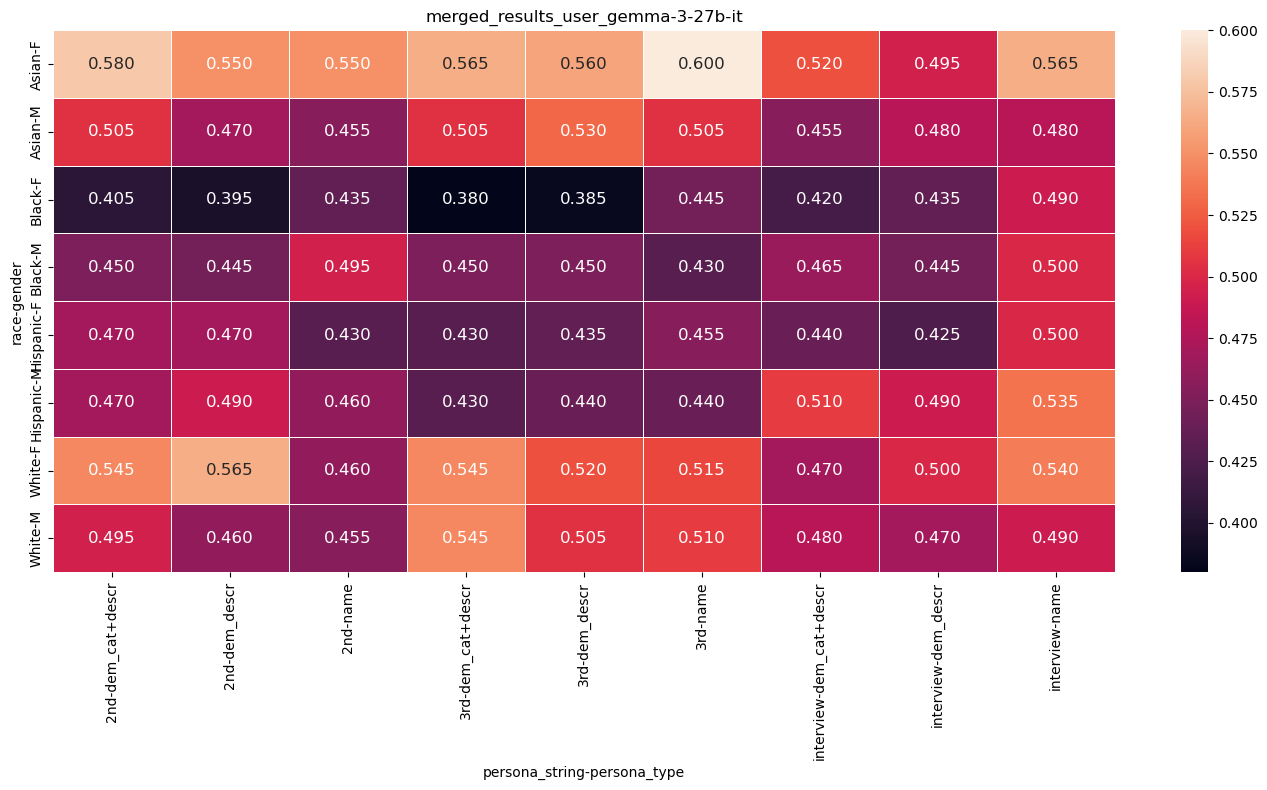

In [23]:
heatmap_df = alignment_df[llm].groupby(['race', 'gender',
                      'persona_type',
                      'persona_string',
                     ]).mean(numeric_only = True)['alignment'].unstack().unstack()
fig, ax = plt.subplots(figsize=(14,8))         # Sample figsize in inches
sns.heatmap(heatmap_df, annot = True, fmt="0.3f", linewidths=.5,
                annot_kws={"size": 12}, ax = ax)
ax.set_title(llm)
plt.tight_layout()
# plt.savefig('../figures/opinionqa_majority_match%s.pdf' %llm)

In [24]:
all_dfs = []

for llm in LLMs:
    alignment_df[llm]['model'] = [llm.split('merged_results_user_')[1]] * len(alignment_df[llm])
    all_dfs.append(alignment_df[llm])
    
to_plot_df = pd.concat(all_dfs, ignore_index=True)
to_plot_df

,gender,race,persona_type,persona_string,prompt_version,alignment,model
0,F,White,dem_cat+descr,2nd,v1,0.72,OLMo-2-0325-32B-Instruct
1,F,White,dem_cat+descr,2nd,v2,0.72,OLMo-2-0325-32B-Instruct
2,F,White,dem_cat+descr,3rd,v1,0.64,OLMo-2-0325-32B-Instruct
3,F,White,dem_cat+descr,3rd,v2,0.66,OLMo-2-0325-32B-Instruct
4,F,White,dem_cat+descr,interview,v1,0.66,OLMo-2-0325-32B-Instruct
...,...,...,...,...,...,...,...
715,M,Black,name,2nd,v2,0.49,gemma-3-27b-it
716,M,Black,name,3rd,v1,0.39,gemma-3-27b-it
717,M,Black,name,3rd,v2,0.47,gemma-3-27b-it
718,M,Black,name,interview,v1,0.50,gemma-3-27b-it


In [25]:
### change vocab

roles = {'2nd': 'Direct',
         '3rd': 'Third Person',
         'interview': 'Interview'
        }
primings = {'name' : 'Name',
            'dem_descr': 'Explicit',
            'dem_cat+descr': 'Structured'}

to_plot_df = to_plot_df.rename(columns = {'persona_string': 'Role Adoption',
                                'persona_type': 'Demographic Priming'})

to_plot_df['Role Adoption'] = [roles[i] for i in to_plot_df['Role Adoption']]
to_plot_df['Demographic Priming'] = [primings[i] for i in to_plot_df['Demographic Priming']]
to_plot_df['task'] = 'QA'
to_plot_df

,gender,race,Demographic Priming,Role Adoption,prompt_version,alignment,model,task
0,F,White,Structured,Direct,v1,0.72,OLMo-2-0325-32B-Instruct,QA
1,F,White,Structured,Direct,v2,0.72,OLMo-2-0325-32B-Instruct,QA
2,F,White,Structured,Third Person,v1,0.64,OLMo-2-0325-32B-Instruct,QA
3,F,White,Structured,Third Person,v2,0.66,OLMo-2-0325-32B-Instruct,QA
4,F,White,Structured,Interview,v1,0.66,OLMo-2-0325-32B-Instruct,QA
...,...,...,...,...,...,...,...,...
715,M,Black,Name,Direct,v2,0.49,gemma-3-27b-it,QA
716,M,Black,Name,Third Person,v1,0.39,gemma-3-27b-it,QA
717,M,Black,Name,Third Person,v2,0.47,gemma-3-27b-it,QA
718,M,Black,Name,Interview,v1,0.50,gemma-3-27b-it,QA


In [26]:
to_plot_df.groupby('Demographic Priming').size()

Demographic Priming
Explicit      240
Name          240
Structured    240
dtype: int64

In [27]:
TASKS = ['QA']

MODELS = [
    "gemma-3-27b-it",
    "OLMo-2-1124-7B-Instruct",
    "OLMo-2-0325-32B-Instruct",
    "Llama-3.1-8B-Instruct",
    "Llama-3.3-70B-Instruct",
]

# Define desired orders
gender_order = ['F', 'M']
race_order = ['White', 'Black', 'Asian', 'Hispanic']
role_order = ['Direct', 'Third Person', 'Interview']
priming_order = ['Name', 'Explicit', 'Structured']
version_order = ['v1', 'v2']  # prompt versions


def plot_heatmaps_(df:pd.DataFrame, metric:str, save_path:str = None, title:str = None,
                  cbar_label:str = None, vmin:float = 0, vmax:float = None, cmap:str = 'crest',
                  margins:bool = True, versions:bool = False, fontsize:int = 10.5) -> None:
    """
    Parameters
    ---
    - `df`         – pd.DataFrame with the columns gender, race, Demographic Priming, Role Adoption, METRIC
    - `metric`     – aggregated metric by socio-demographic x persona group
    - `save_path`  – where to write the plots to
    - `title`      – title of the heatmap, may contain {task} and {model} to be automatically added
    - `cbar_label` – label of the color bar
    - `margins`    – whether to add summary statistics to the margins
    - `versions`   – whether to plot prompt versions separately, requires `prompt_version` column in df
    """

    for task in TASKS:
        for model in MODELS:

            plot_df = df[(df.model == model) & (df.task == task)].copy()
            
            # Create MultiIndex keys
            plot_df['x_multi'] = list(zip(plot_df['race'], plot_df['gender']))
            if versions: plot_df['y_multi'] = list(zip(plot_df['Demographic Priming'],
                                                       plot_df['Role Adoption'],
                                                       plot_df['prompt_version']))
            else: plot_df['y_multi'] = list(zip(plot_df['Demographic Priming'], plot_df['Role Adoption']))

            # Create full x and y MultiIndex
            x_index = pd.MultiIndex.from_product([race_order, gender_order], names=["Race", "Gender"])
            if versions: y_index = pd.MultiIndex.from_product([priming_order,
                                                               role_order,
                                                               version_order],
                                                              names=["Demographic Priming",
                                                                     "Role Adoption",
                                                                     "Prompt Version"])
            else: y_index = pd.MultiIndex.from_product([priming_order, role_order],
                                                       names=["Demographic Priming", "Role Adoption"])

            # Create full matrix with NaNs for missing combinations
            heatmap_data = plot_df.pivot(index='y_multi', columns='x_multi', values=metric)
            heatmap_data = heatmap_data.reindex(index=y_index, columns=x_index)

            # Add summary statistics on marginals
            heatmap_data_augmented = heatmap_data.copy()
            
            if margins:
                if versions: y_mean_index = ('', 'mean', '')  # could also use r'$\mathit{mean}$' for italic
                else: y_mean_index = ('', 'mean')
                heatmap_data_augmented = pd.concat([
                    heatmap_data_augmented,
                    pd.DataFrame({('', 'mean', ''): heatmap_data_augmented.mean(axis=1)}),
                    #pd.DataFrame({('', 'std'): heatmap_data_augmented.std(axis=1)})
                        ], axis=1)
                heatmap_data_augmented = pd.concat([
                    heatmap_data_augmented,
                    pd.DataFrame({y_mean_index: heatmap_data_augmented.mean(axis=0)}).T,
                    #pd.DataFrame({('', 'std'): heatmap_data_augmented.std(axis=0)}).T
                        ], axis=0)
                #heatmap_data_augmented.loc[[('', 'mean'), ('', 'std')], [('', 'mean'), ('', 'std')]] = np.NaN  # remove the corner
                y_index = y_index.append(pd.MultiIndex.from_tuples([y_mean_index]))
                x_index = x_index.append(pd.MultiIndex.from_tuples([('', 'mean')]))

            # Plot heatmap
            fig, ax = plt.subplots(figsize=(11, 4.5))
            sns.heatmap(
                heatmap_data_augmented,
                annot=True,
                fmt=".2f",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                annot_kws={'fontsize': fontsize},
                #linewidths=0.5,
                #linecolor='lightgray',
                cbar_kws={"label": cbar_label},
                ax=ax
            )

            # Set tick labels
            ax.set_xticks(np.arange(len(x_index)) + 0.5)
            ax.set_xticklabels([g for (r, g) in x_index], rotation=0, fontsize=fontsize)
            ax.xaxis.tick_top()
            ax.set_yticks(np.arange(len(y_index)) + 0.5)
            if versions: ax.set_yticklabels([f'{s} ({v})' if s != 'mean' else s for (t, s, v) in y_index],
                                            fontsize=fontsize)
            else: ax.set_yticklabels([s for (t, s) in y_index], fontsize=fontsize)

            ax.set_xlabel("")
            ax.set_ylabel("")

            # Plot lines between racial groups
            _xdist = -1.6 if versions else -.8

            _xstep = int(len(heatmap_data_augmented.columns)/len(race_order))
            _xlines = list(np.arange(_xstep, len(heatmap_data_augmented.columns), _xstep))  # spacing changes if versions are enabled
            plt.vlines(x=_xlines, ymin=_xdist, ymax=len(heatmap_data_augmented), colors='black',
                       clip_on=False)
            #if margins: plt.vlines(x=[len(heatmap_data_augmented.columns)-1], ymin=-1, ymax=100, lw=3, color='white', zorder=10) # separate the means

            # Annotate race groups above gender labels
            race_midpoints = []
            race_labels = []
            for race in race_order:
                indices = [i for i, (r, _) in enumerate(x_index) if r == race]
                if indices:
                    midpoint = np.mean([i + 0.5 for i in indices])
                    race_midpoints.append(midpoint)
                    race_labels.append(race)

            for mid, label in zip(race_midpoints, race_labels):
                ax.text(mid, _xdist, label, ha='center', va='center', fontsize=fontsize,
                        fontweight='bold')


            # Plot lines between Demographic Priming
            _ydist = -3.1 if versions else -2.5

            _ystep = int(len(heatmap_data_augmented)/len(priming_order))
            _ylines = list(np.arange(_ystep, len(heatmap_data_augmented), _ystep))  # spacing changes if versions are enabled
            plt.hlines(y=_ylines, xmin=_ydist, xmax=len(heatmap_data_augmented.columns),
                       colors='black', clip_on=False)  # do not clip, so that we can draw between the yticklabels
            #if margins: plt.hlines(y=[len(heatmap_data_augmented)-1], xmin=-1, xmax=100, lw=3, color='white', zorder=10) # separate the means
            if versions:
                _ylines = list(np.arange(2, len(heatmap_data_augmented)-1, 2))
                plt.hlines(y=_ylines, xmin=-1, xmax=100, lw=0.4, colors='black')  # lines between Role Adoption

            # Annotate Demographic Priming groups
            ptype_midpoints = []
            ptype_labels = []
            for ptype in y_index.get_level_values(0).unique():
                if versions: indices = [i for i, (p, _, _) in enumerate(y_index) if p == ptype]
                else: indices = [i for i, (p, _) in enumerate(y_index) if p == ptype]
                if indices:
                    midpoint = np.mean([i + 0.5 for i in indices])
                    ptype_midpoints.append(midpoint)
                    ptype_labels.append(ptype)

            for mid, label in zip(ptype_midpoints, ptype_labels):
                ax.text(_ydist, mid, label, ha='right', va='center', fontsize=fontsize,
                        fontweight='bold', rotation=90) # -2.3

            ax.figure.axes[-1].yaxis.label.set_size(fontsize)
            #plt.title(title.format(task=task, model=model), pad=19)  # the standard title is incompatible with our xticklabels
            plt.tight_layout()

            if save_path is not None:
                plt.savefig(f'{save_path}/{task}_{metric}_heatmap_{model}.pdf',
                            bbox_inches="tight", dpi=300)


In [28]:
to_plot_df.to_csv("../data/temp/OpinionsQA_Majority_Match_with_versions.csv", index = False)

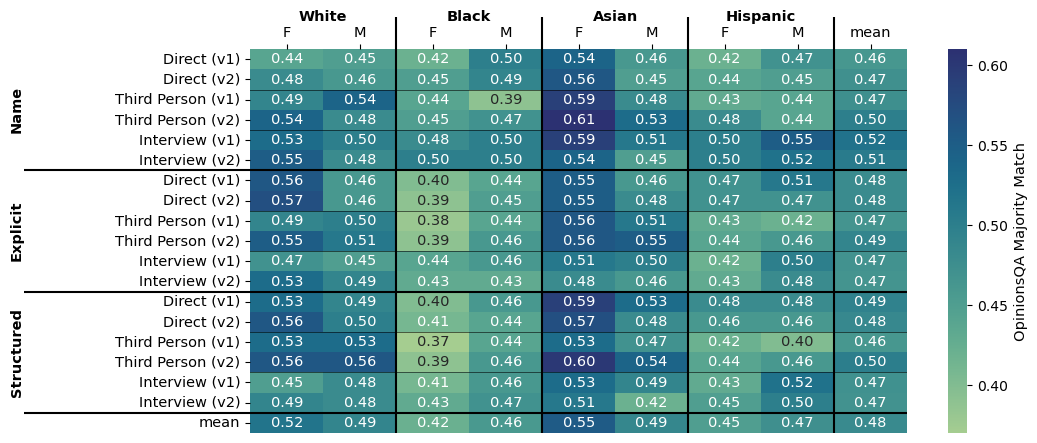

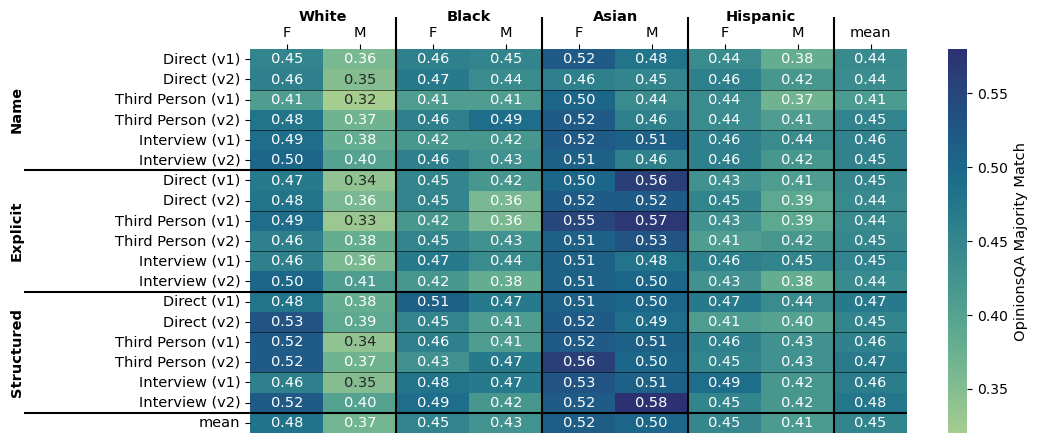

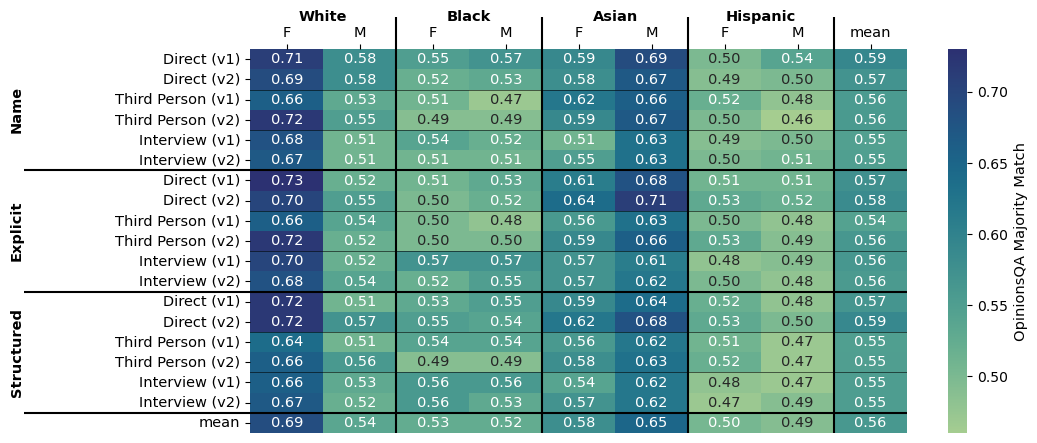

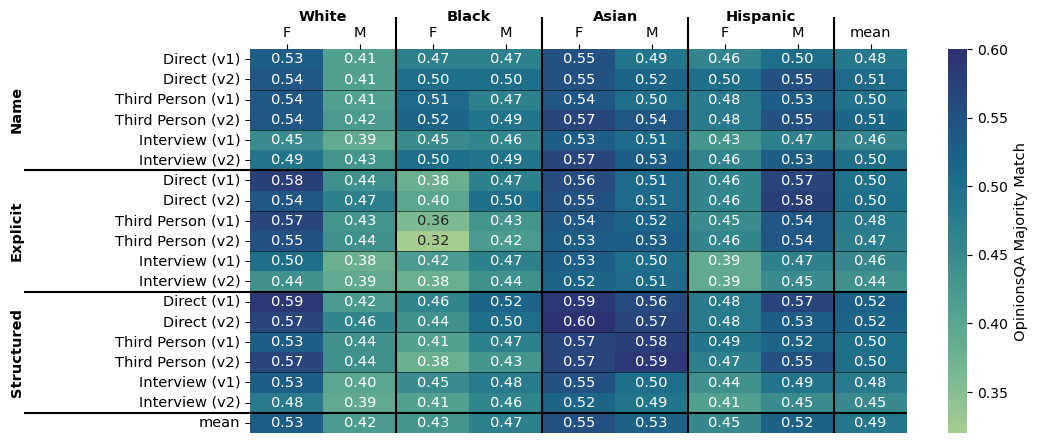

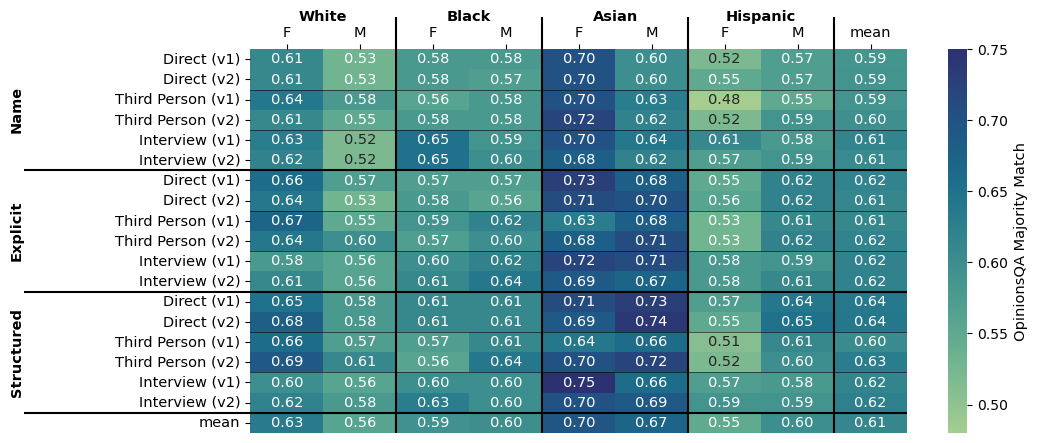

In [29]:
metric = 'alignment'
plot_heatmaps_(df=to_plot_df, metric=metric,
              cbar_label='OpinionsQA Majority Match',
              vmin=None,# vmax=max_metric,
              # save_path = '../figures/majority_match/',
              cmap='crest', versions = versions)

### Distribution Match

#### get model distributions 

In [30]:
for llm in LLMs:
    D_Ms, R_Ms = [], []
    df = data[llm].copy()
    for n, row in df.iterrows():
        lps = ast.literal_eval(df['answer_dist_clean'][n])
        options = ast.literal_eval(df['qa_options'][n])
        res = ph.get_probabilities_custom(lps, options)
        ordinal = len(options) - 1
        D_Ms.append(res['probs_unnorm'][:ordinal] / np.sum(res['probs_unnorm'][:ordinal]))
        R_Ms.append(np.sum(res['probs_norm'][ordinal:]))
    data[llm]['D_M'] = D_Ms
    data[llm]['R_M'] = R_Ms

#### find overall alignment based on formula (1) in the OpinionQA paper

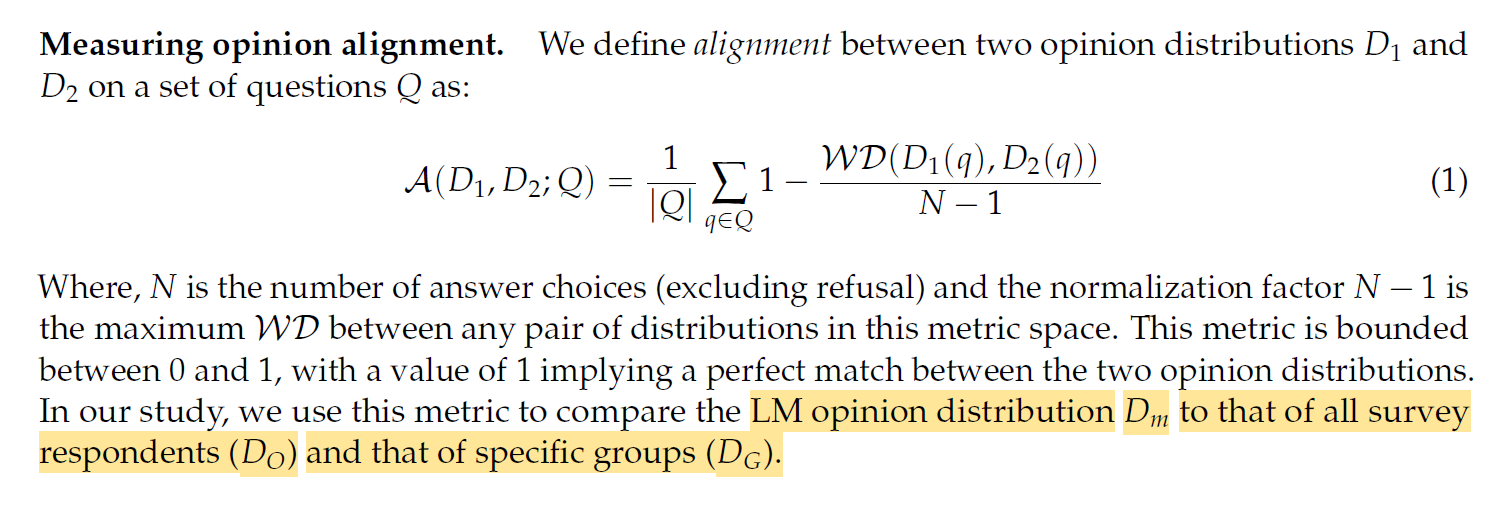

In [31]:
def compute_alignment(human_df_subset, model_df_subset = False, baseline =  False):
    alignment = []
    if not baseline:
        all_qkeys = set(model_df_subset['qa_key'].unique())
        all_qkeys = list(all_qkeys.intersection(human_df_subset['qkey'].unique()))
        for qkey in all_qkeys:
            d1 = model_df_subset[model_df_subset['qa_key'] == qkey]['D_M'].values[0]
            d2 = human_df_subset[human_df_subset['qkey'] == qkey]['D_H'].values[0]
            wd_m = 1 - (wasserstein_distance(d1, d2) / (len(d1)-1)) # this metric is a bit sketchy
            wd_m = wasserstein_distance(d1, d2) # used in https://arxiv.org/pdf/2502.16761
            alignment.append(wd_m)
    else:
        ## upper bound for wd
        all_qkeys = human_df_subset['qkey'].unique()
        for qkey in all_qkeys:
            d2 = human_df_subset[human_df_subset['qkey'] == qkey]['D_H'].values[0]
            d1 = np.random.dirichlet(np.ones(len(d2)-1)).tolist() # random
            wd_m = 1 - (wasserstein_distance(d1, d2) / (len(d1)-1)) # this metric is a bit sketchy
            wd_m = wasserstein_distance(d1, d2) # used in https://arxiv.org/pdf/2502.16761
            alignment.append(wd_m)
        
    
    return(np.mean(alignment))

In [32]:
qa_demo_map = {'F': 'Female',
               'M' : 'Male'}

genders = ['F', 'M']
persona_types = data[llm]['persona_type'].unique()
persona_strings = data[llm]['persona_string'].unique()
prompt_versions = data[llm]['prompt_version'].unique()

baseline_df_rows = []

for gender in genders:
    human_df_subset = human_df[human_df['group'] == qa_demo_map[gender]]
    
    for race in races:
        human_df_subset_r = human_df_subset[human_df_subset['RACE'] == race]
        
        ## get random bound
        for i in range(100):
            alignment = compute_alignment(human_df_subset_r, baseline = True)
            baseline_df_row = [gender, race, 'random',
                                        alignment]
            baseline_df_rows.append(baseline_df_row)
        
baseline_df = pd.DataFrame(baseline_df_rows)
baseline_df.columns = ['gender', 'race', 'persona_type',
                        'alignment']

C:\Users\isen1\AppData\Local\Temp\ipykernel_24568\2597469370.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  wd_m = 1 - (wasserstein_distance(d1, d2) / (len(d1)-1)) # this metric is a bit sketchy


In [33]:
qa_demo_map = {'F': 'Female',
               'M' : 'Male'}

genders = ['F', 'M']
persona_types = data[llm]['persona_type'].unique()
persona_strings = data[llm]['persona_string'].unique()
prompt_versions = data[llm]['prompt_version'].unique()

dist_align_df = {}
for llm in LLMs:
    alignment_df_rows = []
    df = data[llm]
    for gender in genders:
        model_df_subset = df[df['gender'] == gender]
        human_df_subset = human_df[human_df['group'] == qa_demo_map[gender]]
    
        for race in races:
            model_df_subset_race = model_df_subset[model_df_subset['race'] == race]
            human_df_subset_r = human_df_subset[human_df_subset['RACE'] == race]
        
            for persona_type in ['dem_cat+descr', 'dem_descr', 'name']:
                model_df_subset_pt = model_df_subset_race[model_df_subset_race['persona_type']\
                                                   == persona_type]
            
                
            
                for persona_string in persona_strings:
                    model_df_subset_ps = model_df_subset_pt[model_df_subset_pt['persona_string']\
                                                        == persona_string]
                
                    if versions:
                        for prompt_version in prompt_versions:
                            model_df_subset_pv = model_df_subset_ps[model_df_subset_ps['prompt_version'] == \
                                                      prompt_version]
                            alignment = compute_alignment(human_df_subset_r,
                                                      model_df_subset_pv)
                            alignment_df_row = [gender, race, persona_type,
                                        persona_string, prompt_version,
                                        alignment]
                            alignment_df_rows.append(alignment_df_row)
                    else:
                        alignment = compute_alignment(human_df_subset_r,
                                                      model_df_subset_ps)
                        alignment_df_row = [gender, race, persona_type,
                                        persona_string, # prompt_version,
                                        alignment]
                        alignment_df_rows.append(alignment_df_row)
                        
                    

    alignment_df = pd.DataFrame(alignment_df_rows)
    if versions:
        alignment_df.columns = ['gender', 'race', 'persona_type',
                        'persona_string', 'prompt_version',
                        'alignment']
    else:
        alignment_df.columns = ['gender', 'race', 'persona_type',
                        'persona_string', # 'prompt_version',
                        'alignment']
    dist_align_df[llm] =  alignment_df

In [34]:
dist_align_df[llm].groupby('persona_string').size()

persona_string
2nd          48
3rd          48
interview    48
dtype: int64

In [35]:
means = baseline_df.groupby(['gender', 'race', 'persona_type'])['alignment'].mean().unstack()
stds = baseline_df.groupby(['gender', 'race', 'persona_type'])['alignment'].std().unstack()
bl_df = pd.concat([means.T, stds.T]).T
bl_df.columns = ['mean', 'std']
bl_df

mean       std
gender race                        
F      Asian     0.248585  0.002359
       Black     0.246345  0.002332
       Hispanic  0.246692  0.002254
       White     0.248554  0.002434
M      Asian     0.247530  0.002331
       Black     0.246827  0.002354
       Hispanic  0.247727  0.002355
       White     0.250665  0.002756

In [36]:
bl_df.mean()

mean    0.247866
std     0.002397
dtype: float64

In [37]:
dist_align_df[llm].columns

Index(['gender', 'race', 'persona_type', 'persona_string', 'prompt_version',
       'alignment'],
      dtype='object')

In [38]:
dist_align_df[llm].groupby(['race', 'gender',
                      # 'prompt_version',
                      'persona_type',
                      'persona_string',
                     ]).mean(numeric_only = True)['alignment'].unstack().unstack().unstack()

persona_string           2nd                                          \
persona_type   dem_cat+descr           dem_descr                name   
gender                     F         M         F         M         F   
race                                                                   
Asian               0.245765  0.246305  0.247774  0.244768  0.248362   
Black               0.243369  0.227210  0.245725  0.228361  0.241688   
Hispanic            0.237078  0.240613  0.235459  0.239253  0.234975   
White               0.268118  0.276669  0.272185  0.280777  0.273393   

persona_string                     3rd                                \
persona_type             dem_cat+descr           dem_descr             
gender                 M             F         M         F         M   
race                                                                   
Asian           0.251051      0.245452  0.246949  0.247675  0.246259   
Black           0.228183      0.241684  0.228616  0.244896  0.232406   
Hispanic        0.240530      0.233635  0.241452  0.234966  0.239006   
White           0.279778      0.264316  0.273683  0.270628  0.278939   

persona_string                         interview                      \
persona_type        name           dem_cat+descr           dem_descr   
gender                 F         M             F         M         F   
race                                                                   
Asian           0.246246  0.244954      0.236693  0.236923  0.242307   
Black           0.240720  0.223221      0.234012  0.222223  0.231667   
Hispanic        0.233575  0.240109      0.229700  0.235274  0.226711   
White           0.270124  0.280871      0.264544  0.275426  0.264299   

persona_string                                
persona_type                  name            
gender                 M         F         M  
race                                          
Asian           0.241691  0.243924  0.241077  
Black           0.222362  0.240077  0.222946  
Hispanic        0.233247  0.234304  0.237851  
White           0.275510  0.271570  0.279393

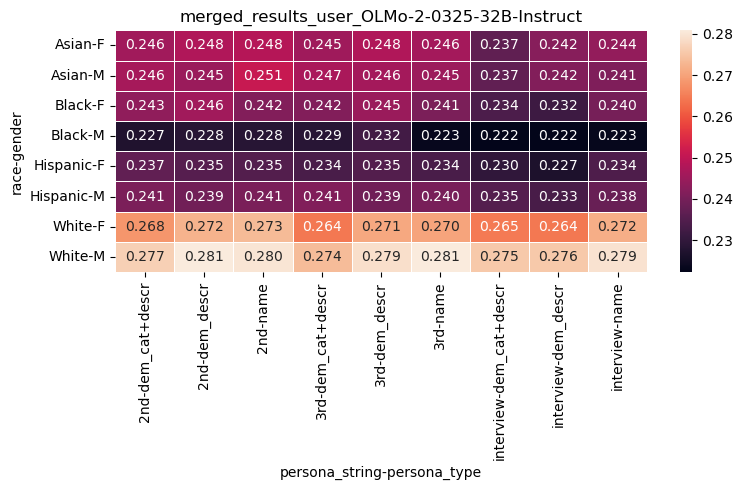

In [39]:
heatmap_df = dist_align_df[llm].groupby(['race', 'gender',
                      # 'prompt_version',
                      'persona_type',
                      'persona_string',
                     ]).mean(numeric_only = True)['alignment'].unstack().unstack()
fig, ax = plt.subplots(figsize=(8,5))         # Sample figsize in inches
sns.heatmap(heatmap_df, annot = True, fmt="0.3f", linewidths=.5,
                annot_kws={"size": 10}, ax = ax)
ax.set_title(LLMs[0])
plt.tight_layout()
# plt.savefig('../figures/opinionqa_%s.pdf' %LLMs[0])

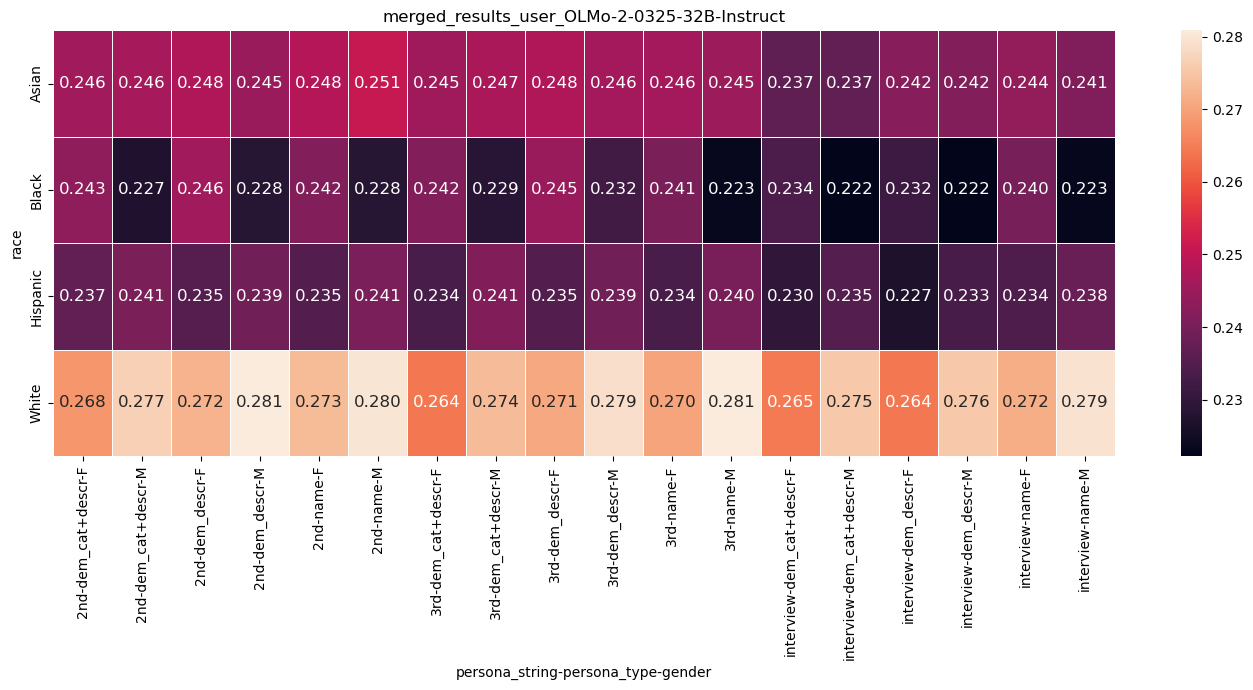

In [40]:
heatmap_df = dist_align_df[llm].groupby(['race', 'gender',
                      # 'prompt_version',
                      'persona_type',
                      'persona_string',
                     ]).mean(numeric_only = True)['alignment'].unstack().unstack().unstack()
fig, ax = plt.subplots(figsize=(14,7))         # Sample figsize in inches
sns.heatmap(heatmap_df, annot = True, fmt="0.3f", linewidths=.5,
                annot_kws={"size": 12}, ax = ax)
ax.set_title(LLMs[0])
plt.tight_layout()
# plt.savefig('../figures/opinionqa_v1v2%s.pdf' %LLMs[0])

In [41]:
human_df_subset_r

,qkey,attribute,group,D_H,R_H,RACE,A_H
697,ECIMPg_W54,SEX,Male,"[0.8555374955003903, 0.03826832829481403, 0.10619417620479576]",0.000000,Black,0
699,GOVRESP_a_W54,SEX,Male,"[0.7247309894913784, 0.2752690105086215]",0.003883,Black,0
701,ECON3_d_W54,SEX,Male,"[0.5926019343324429, 0.23893234461469545, 0.10369931327880536, 0.06476640777405616]",0.012626,Black,0
703,INEQ7_W54,SEX,Male,"[0.5509675979911578, 0.334144342948756, 0.08838832586439153, 0.026499733195694816]",0.001541,Black,0
705,ECIMPc_W54,SEX,Male,"[0.2219245046538371, 0.46380398620640584, 0.314271509139757]",0.027762,Black,1
...,...,...,...,...,...,...,...
2367,COMPROMISEVAL_W92,SEX,Male,"[0.25968265863212314, 0.7403173413678769]",0.024641,Black,1
2369,INSTN_MSCENT_W92,SEX,Male,"[0.5171428270549636, 0.4828571729450363]",0.002839,Black,0
2371,PPLRESP_W92,SEX,Male,"[0.667774063477796, 0.33222593652220395]",0.004021,Black,0
2373,GOVTHC_W92,SEX,Male,"[0.8080760565279501, 0.1919239434720498]",0.014832,Black,0


In [42]:
dist_align_df[llm]

,gender,race,persona_type,persona_string,prompt_version,alignment
0,F,White,dem_cat+descr,2nd,v1,0.265880
1,F,White,dem_cat+descr,2nd,v2,0.270356
2,F,White,dem_cat+descr,3rd,v1,0.267271
3,F,White,dem_cat+descr,3rd,v2,0.261360
4,F,White,dem_cat+descr,interview,v1,0.266876
...,...,...,...,...,...,...
139,M,Black,name,2nd,v2,0.227022
140,M,Black,name,3rd,v1,0.224129
141,M,Black,name,3rd,v2,0.222313
142,M,Black,name,interview,v1,0.222900


In [43]:
all_dfs = []

for llm in LLMs:
    dist_align_df[llm]['model'] = [llm.split('merged_results_user_')[1]] \
    * len(dist_align_df[llm])
    all_dfs.append(dist_align_df[llm])
    
to_plot_df = pd.concat(all_dfs, ignore_index=True)
to_plot_df

,gender,race,persona_type,persona_string,prompt_version,alignment,model
0,F,White,dem_cat+descr,2nd,v1,0.207190,OLMo-2-0325-32B-Instruct
1,F,White,dem_cat+descr,2nd,v2,0.200534,OLMo-2-0325-32B-Instruct
2,F,White,dem_cat+descr,3rd,v1,0.203931,OLMo-2-0325-32B-Instruct
3,F,White,dem_cat+descr,3rd,v2,0.199867,OLMo-2-0325-32B-Instruct
4,F,White,dem_cat+descr,interview,v1,0.192157,OLMo-2-0325-32B-Instruct
...,...,...,...,...,...,...,...
715,M,Black,name,2nd,v2,0.227022,gemma-3-27b-it
716,M,Black,name,3rd,v1,0.224129,gemma-3-27b-it
717,M,Black,name,3rd,v2,0.222313,gemma-3-27b-it
718,M,Black,name,interview,v1,0.222900,gemma-3-27b-it


In [44]:
### change vocab

roles = {'2nd': 'Direct',
         '3rd': 'Third Person',
         'interview': 'Interview'
        }
primings = {'name' : 'Name',
            'dem_descr': 'Explicit',
            'dem_cat+descr': 'Structured'}

to_plot_df = to_plot_df.rename(columns = {'persona_string': 'Role Adoption',
                                'persona_type': 'Demographic Priming'})

to_plot_df['Role Adoption'] = [roles[i] for i in to_plot_df['Role Adoption']]
to_plot_df['Demographic Priming'] = [primings[i] for i in to_plot_df['Demographic Priming']]
to_plot_df['task'] = 'QA'
to_plot_df

,gender,race,Demographic Priming,Role Adoption,prompt_version,alignment,model,task
0,F,White,Structured,Direct,v1,0.207190,OLMo-2-0325-32B-Instruct,QA
1,F,White,Structured,Direct,v2,0.200534,OLMo-2-0325-32B-Instruct,QA
2,F,White,Structured,Third Person,v1,0.203931,OLMo-2-0325-32B-Instruct,QA
3,F,White,Structured,Third Person,v2,0.199867,OLMo-2-0325-32B-Instruct,QA
4,F,White,Structured,Interview,v1,0.192157,OLMo-2-0325-32B-Instruct,QA
...,...,...,...,...,...,...,...,...
715,M,Black,Name,Direct,v2,0.227022,gemma-3-27b-it,QA
716,M,Black,Name,Third Person,v1,0.224129,gemma-3-27b-it,QA
717,M,Black,Name,Third Person,v2,0.222313,gemma-3-27b-it,QA
718,M,Black,Name,Interview,v1,0.222900,gemma-3-27b-it,QA


In [45]:
to_plot_df['model'].unique()

array(['OLMo-2-0325-32B-Instruct', 'OLMo-2-1124-7B-Instruct',
       'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct',
       'gemma-3-27b-it'], dtype=object)

#### stats for table 1

Marlene's code:

display(res_df.groupby(["Demographic Priming", "Role Adoption"])[metric].mean())
display(res_df.groupby(["Demographic Priming", "Role Adoption", "model"])[metric].mean().groupby(["Demographic Priming", "Role Adoption"]).std())

In [46]:
to_plot_df__ = to_plot_df[to_plot_df['model'].isin(['OLMo-2-0325-32B-Instruct',
                                                    'OLMo-2-1124-7B-Instruct',
       'Llama-3.1-8B-Instruct'])]

In [47]:
to_plot_df__.groupby(['Demographic Priming', 'Role Adoption']).mean(numeric_only =True)

alignment
Demographic Priming Role Adoption           
Explicit            Direct          0.165900
                    Interview       0.151414
                    Third Person    0.167524
Name                Direct          0.163719
                    Interview       0.155211
                    Third Person    0.163397
Structured          Direct          0.165435
                    Interview       0.146916
                    Third Person    0.166767

In [48]:
to_plot_df__.groupby(["Demographic Priming", "Role Adoption", "model"]).mean(numeric_only = True).groupby(["Demographic Priming", "Role Adoption"]).std(numeric_only = True)

alignment
Demographic Priming Role Adoption           
Explicit            Direct          0.027875
                    Interview       0.028169
                    Third Person    0.023652
Name                Direct          0.028968
                    Interview       0.018322
                    Third Person    0.022934
Structured          Direct          0.026187
                    Interview       0.024634
                    Third Person    0.023771

In [49]:
to_plot_df__.groupby(['Demographic Priming', 'Role Adoption']).std(numeric_only =True)

alignment
Demographic Priming Role Adoption           
Explicit            Direct          0.027009
                    Interview       0.027462
                    Third Person    0.023472
Name                Direct          0.028400
                    Interview       0.020871
                    Third Person    0.024312
Structured          Direct          0.025692
                    Interview       0.025043
                    Third Person    0.023501

In [50]:
# get the mean values disaggregated by prompt type and model
grouped_means = to_plot_df__.groupby(["Demographic Priming",
                                      "Role Adoption",
                                      "model"]).mean(numeric_only=True).reset_index()
# normalize per model
grouped_means["normalized_metric"] = grouped_means.groupby(["model"])['alignment'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# compute the mean and std of the normalized values across models
summary_stats = grouped_means.groupby(["Demographic Priming", "Role Adoption"])["normalized_metric"].agg(
    mean_normalized_metric="mean",
    std_normalized_metric="std"
).reset_index()
display(summary_stats)

,Demographic Priming,Role Adoption,mean_normalized_metric,std_normalized_metric
0,Explicit,Direct,0.744601,0.098632
1,Explicit,Interview,0.172788,0.143066
2,Explicit,Third Person,0.825536,0.254536
3,Name,Direct,0.642660,0.316295
4,Name,Interview,0.344700,0.313342
5,Name,Third Person,0.643380,0.327475
6,Structured,Direct,0.734641,0.159797
7,Structured,Interview,0.000000,0.000000
8,Structured,Third Person,0.800908,0.344838


In [51]:
### Marlene's normalization code

'''
# get the mean values disaggregated by prompt type and model
grouped_means = res_df.groupby(["Demographic Priming", "Role Adoption", "model"])[metric].mean().reset_index()
# normalize per model
grouped_means["normalized_metric"] = grouped_means.groupby(["model"])[metric].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

# compute the mean and std of the normalized values across models
summary_stats = grouped_means.groupby(["Demographic Priming", "Role Adoption"])["normalized_metric"].agg(
    mean_normalized_metric="mean",
    std_normalized_metric="std"
).reset_index()
display(summary_stats)
'''
 

'\n# get the mean values disaggregated by prompt type and model\ngrouped_means = res_df.groupby(["Demographic Priming", "Role Adoption", "model"])[metric].mean().reset_index()\n# normalize per model\ngrouped_means["normalized_metric"] = grouped_means.groupby(["model"])[metric].transform(\n    lambda x: (x - x.min()) / (x.max() - x.min())\n)\n\n# compute the mean and std of the normalized values across models\nsummary_stats = grouped_means.groupby(["Demographic Priming", "Role Adoption"])["normalized_metric"].agg(\n    mean_normalized_metric="mean",\n    std_normalized_metric="std"\n).reset_index()\ndisplay(summary_stats)\n'

In [52]:
to_plot_df.to_csv("../data/temp/OpinionsQA_Distribution_Match_with_versions.csv", index = False)

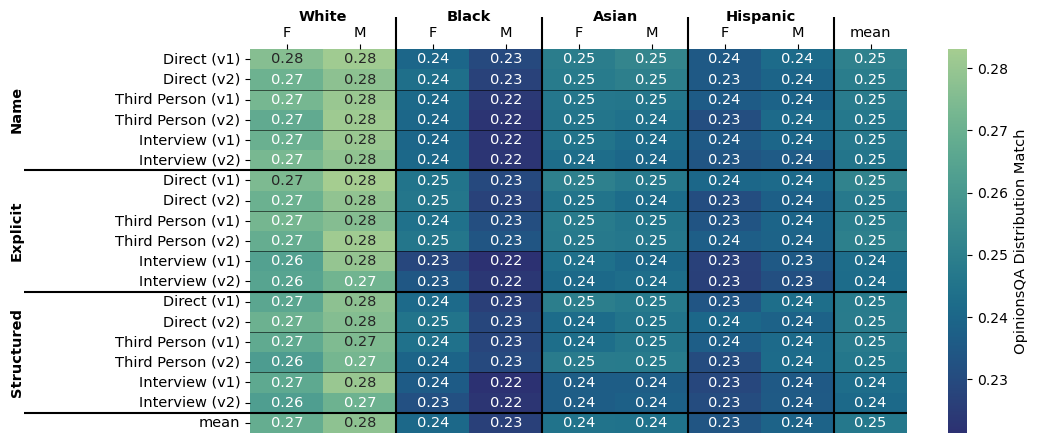

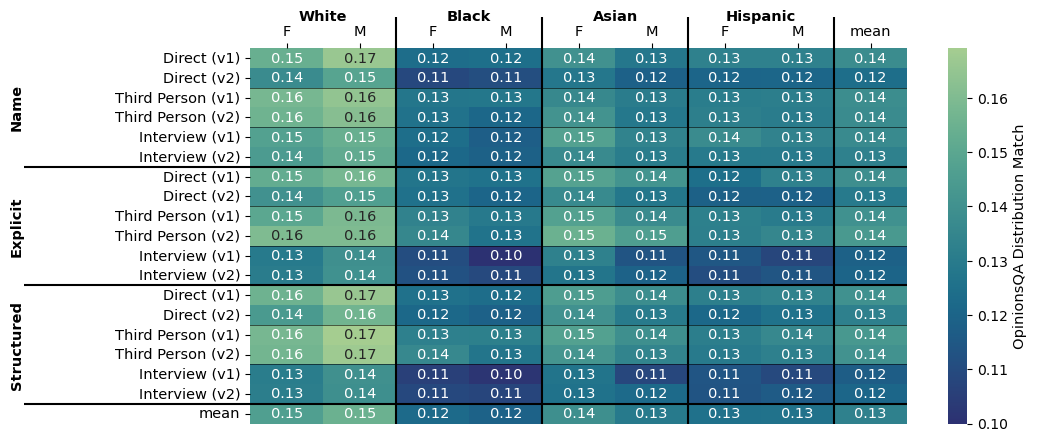

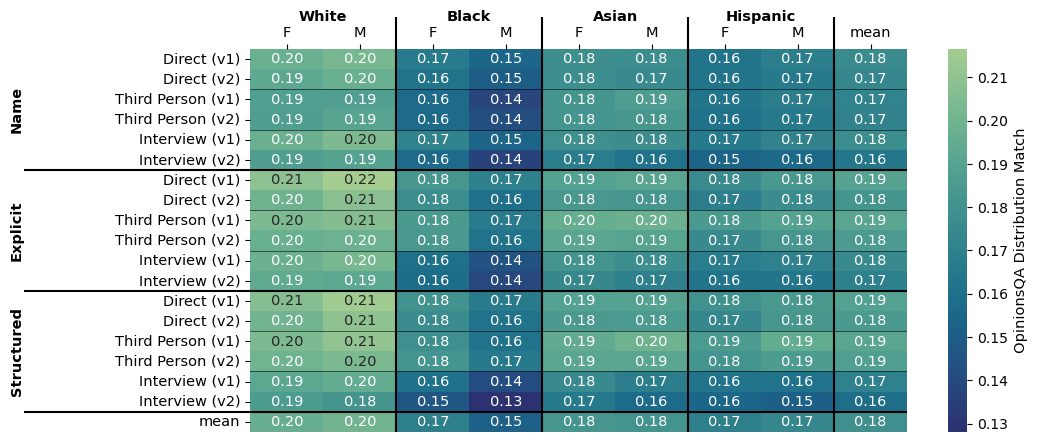

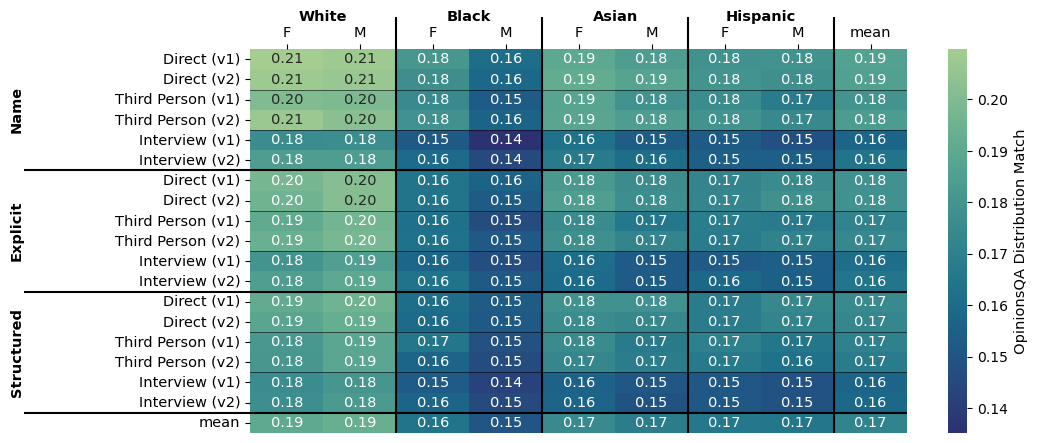

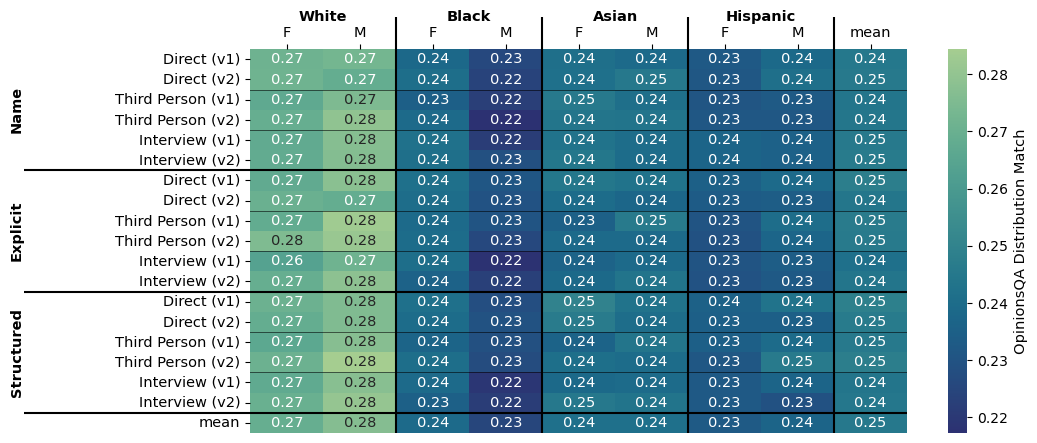

In [53]:
metric = 'alignment'
plot_heatmaps_(df=to_plot_df, metric=metric,
              cbar_label='OpinionsQA Distribution Match',
              vmin=None,# vmax=max_metric,
              save_path = '../figures/distribution_match/',
              cmap='crest_r',
              versions = versions)

In [54]:
model_df_subset[model_df_subset['qa_key'] == 'INEQ8_g_W54'][['race', 'gender', 'D_M']]
model_df_subset[model_df_subset['qa_key'] == 'INEQ8_g_W54'][['race', 'gender', 'D_M', 'R_M']].values[0]

array(['White', 'M',
       array([7.77299784e-01, 2.22700103e-01, 1.12318384e-07, 3.76786202e-11]),
       3.435845422773935e-14], dtype=object)

In [55]:
for i in model_df_subset[model_df_subset['qa_key'] == 'INEQ8_g_W54']['D_M'].values[0]:
    print(i)

0.7772997841581875
0.22270010348575014
1.1231838376177164e-07
3.767862017848673e-11


In [56]:
1 - wasserstein_distance([0.37101322, 0.42041306, 0.12045036, 0.08812336],
                    [0.29081743117913483, 0.2760818779988568, 0.2337358568976907, 0.1993648339243178]
                    #  [0.25, 0.25, 0.25, 0.25] 
                        )#/3


0.8877365145889958

In [57]:
human_df_subset[human_df_subset['qkey'] == 'INEQ8_g_W54']

,qkey,attribute,group,D_H,R_H,RACE,A_H
227,INEQ8_g_W54,SEX,Male,"[0.29081743117913483, 0.2760818779988568, 0.2337358568976907, 0.1993648339243178]",0.00421,White,0
459,INEQ8_g_W54,SEX,Male,"[0.33043202773012875, 0.43562208020029547, 0.1819795934330399, 0.051966298636535985]",0.00000,Asian,1
691,INEQ8_g_W54,SEX,Male,"[0.6082354927093997, 0.2373038485110133, 0.07752518605990925, 0.07693547271967789]",0.00000,Hispanic,0
923,INEQ8_g_W54,SEX,Male,"[0.6365243339386191, 0.20028379765683293, 0.14691963755699025, 0.0162722308475578]",0.00000,Black,0
